# 01. Introduction to Data Science
## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the complete data science lifecycle (9 steps)
- Know what pandas DataFrames are and how they work
- Create basic data visualizations
- Understand the workflow from data to insights
- See how all course units fit into the lifecycle

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process" — profiling one real dataset, now placed inside a full nine-step lifecycle.

**Used later in:** Course 05 — Units 2-5, each of which is one stage of that lifecycle, and Course 12 (AIAT 126) — Unit 1, where a project proposal follows the same arc.

---


## 🎯 One county, two hurricanes, and a flu tracker that skipped step 9

**The lifecycle paying off — Wal-Mart, September 2004.** With Hurricane Frances closing on
Florida, CIO Linda Dillman told her analysts to mine the sales records from Hurricane
Charley a few weeks earlier and forecast what stores would need. The pattern nobody had
guessed: strawberry Pop-Tarts sold at roughly **seven times** their normal rate ahead of a
hurricane (beer sold hardest of all). Trucks were loaded on that forecast and the stock
cleared (Constance L. Hays, *"What Wal-Mart Knows About Customers' Habits"*, The New York
Times, 14 November 2004). Read that story again as the nine steps you are about to draw:
a defined question — *what do we ship to Florida this week?* — then historical data,
exploration, a prediction, and a decision that moved real trucks.

**The failure the lifecycle is built to prevent — Google Flu Trends.** Launched in 2008,
it estimated influenza activity from search queries, was published in *Nature*, and was
genuinely good at first. Then it drifted. In the 2012–13 season it predicted roughly
**twice** the doctor visits the CDC actually recorded, and Google stopped publishing
estimates in August 2015. Lazer, Kennedy, King & Vespignani dissected it in *Science*
(2014) as *"The Parable of Google Flu: Traps in Big Data Analysis"*: the model was not
wrong on day one — it was never re-measured against reality. **Step 9, monitoring, is not
paperwork. Its absence is what killed a famous system.** Course 05 Unit 5 lesson 09 puts a
model of our own through exactly that test.

**Our data is the same kind of object as Wal-Mart's.** The `montgomery_911_calls.csv` you
load below is the real dispatch log of Montgomery County, Pennsylvania — **663,522 calls**
from 10 December 2015 to 29 July 2020, published by the county. Nobody tidied it for
teaching: the ZIP code is missing on about 12% of rows because dispatchers could not always
capture it.


---

---

## The Story: Building a House

Imagine you're building a house. **Before** you start, you need to see the blueprint - understand all the steps (foundation → walls → roof → finishing). **After** seeing the blueprint, you know where each step fits and why the order matters.

Same with data science: **Before** doing any data work, we learn the lifecycle - understand all steps (problem → data → cleaning → modeling → deployment). **After** learning the lifecycle, you know where each technique fits and why order matters!

---

## Why Data Science Lifecycle Matters

Understanding the lifecycle is crucial because:
- **Find Your Place**: Know where you are in any project
- **Understand Order**: Know why steps come in this sequence
- **See Big Picture**: Understand how all parts connect
- **Make Decisions**: Know what to do next at each stage

**Common Student Questions:**
- **Q: What is data science?**
  - Answer: Data science = extract insights from data using statistics, ML, and programming
  - Combines: Statistics (analysis), ML (predictions), Programming (automation)
  - Goal: Turn data into actionable insights
  - Example: Analyze sales data → predict future sales → optimize inventory
- **Q: What's the difference between data science and machine learning?**
  - Answer: Data science = broader field (includes data cleaning, visualization, ML)
  - Machine learning = subset of data science (building predictive models)
  - Data science: Problem → Data → Clean → Explore → Model → Deploy
  - ML: Focus on the "Model" step (training algorithms)
  - Data science includes ML, but also data engineering, visualization, etc.
- **Q: Why is the lifecycle important?**
  - Answer: Lifecycle = roadmap for any data science project
  - Without lifecycle: Random steps, miss important steps, waste time
  - With lifecycle: Systematic approach, know what to do next, efficient
  - Example: Don't model before cleaning data → lifecycle prevents this mistake
- **Q: What is a DataFrame?**
  - Answer: DataFrame = 2D table (rows = samples, columns = features)
  - Like Excel spreadsheet, but in Python (pandas library)
  - Rows = individual data points, Columns = different features/variables
  - Example: 1000 rows (customers), 10 columns (age, income, purchases, etc.)
  - Foundation of all data science work!
- **Q: Why use pandas instead of Excel?**
  - Answer: Pandas = programmatic (automated, reproducible), handles large data
  - Excel: Manual, limited to ~1M rows, hard to automate
  - Pandas: Can process millions of rows, automate workflows, reproducible
  - Example: Clean 1M records in seconds (pandas) vs hours (Excel)

## Learning Objectives
1. Understand the complete data science lifecycle (9 steps)
2. Know what pandas DataFrames are and how they work
3. Create basic data visualizations
4. Understand the workflow from data to insights
5. See how all course units fit into the lifecycle


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries: pandas, numpy, matplotlib, seaborn
- **Real data:** `montgomery_911_calls.csv` - every 911 emergency call logged by
  Montgomery County, Pennsylvania (a public dataset). Real timestamps, real
  coordinates, real gaps in the records.
- Concepts: data science lifecycle (9 steps), DataFrames, FAQ topics

**Outputs:** What you'll see when you run the cells

- Printed summaries and lifecycle diagram (figure)
- Four charts built from the real call log
- FAQ answers and "Next steps" guidance

---


In [1]:
# Step 1: Import necessary libraries
# These libraries help us work with data and create visualizations

import pandas as pd  # For data manipulation and analysis (DataFrames, reading CSV)
import numpy as np   # For numerical operations (arrays, math functions)
import matplotlib.pyplot as plt  # For creating plots and visualizations
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch  # For drawing fancy boxes in plots
import seaborn as sns  # For statistical visualizations (beautiful plots)

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Load, manipulate, and analyze data (our main tool!)")
print("   - numpy: Fast numerical computations (arrays, math)")
print("   - matplotlib: Create basic plots and charts")
print("   - seaborn: Create beautiful statistical visualizations")

✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Load, manipulate, and analyze data (our main tool!)
   - numpy: Fast numerical computations (arrays, math)
   - matplotlib: Create basic plots and charts
   - seaborn: Create beautiful statistical visualizations


In [2]:
# Set style for better plots
# Why seaborn-v0_8? It provides professional-looking plots automatically
# Why set palette? Consistent colors make comparisons easier
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=" * 70)
print("Example 1: Introduction to Data Science")
print("=" * 70)
print("\n📚 Prerequisites: Python basics, pandas, numpy, matplotlib")
print("🔗 This is the FIRST example - foundation for all others")
print("🎯 Goal: Understand the data science lifecycle and basic workflow\n")

Example 1: Introduction to Data Science

📚 Prerequisites: Python basics, pandas, numpy, matplotlib
🔗 This is the FIRST example - foundation for all others
🎯 Goal: Understand the data science lifecycle and basic workflow



## Part 1: Understanding the Data Science Lifecycle

**BEFORE**: You know individual data science techniques but not how they connect.

**AFTER**: You'll understand the complete lifecycle and where each step fits!

**Why this matters**: The lifecycle shows you the big picture - where everything fits!

## Step 1: Creating the Lifecycle Diagram

**BEFORE**: We know data science has steps but don't see how they connect.

**AFTER**: We'll create a visual diagram showing all 9 steps and their relationships!

**Why 9 steps?** They represent the complete journey from problem to production.
**Why in this order?** Each step builds on the previous one - can't skip steps!


PART 1: Understanding the Data Science Lifecycle

📋 BEFORE: You know individual data science techniques but not how they connect
📋 AFTER: You understand the complete lifecycle and where each step fits
💡 WHY THIS MATTERS: The lifecycle shows you the big picture - where everything fits!


1. Creating the Data Science Lifecycle Diagram
----------------------------------------------------------------------
✓ Lifecycle diagram saved as 'data_science_lifecycle.png'


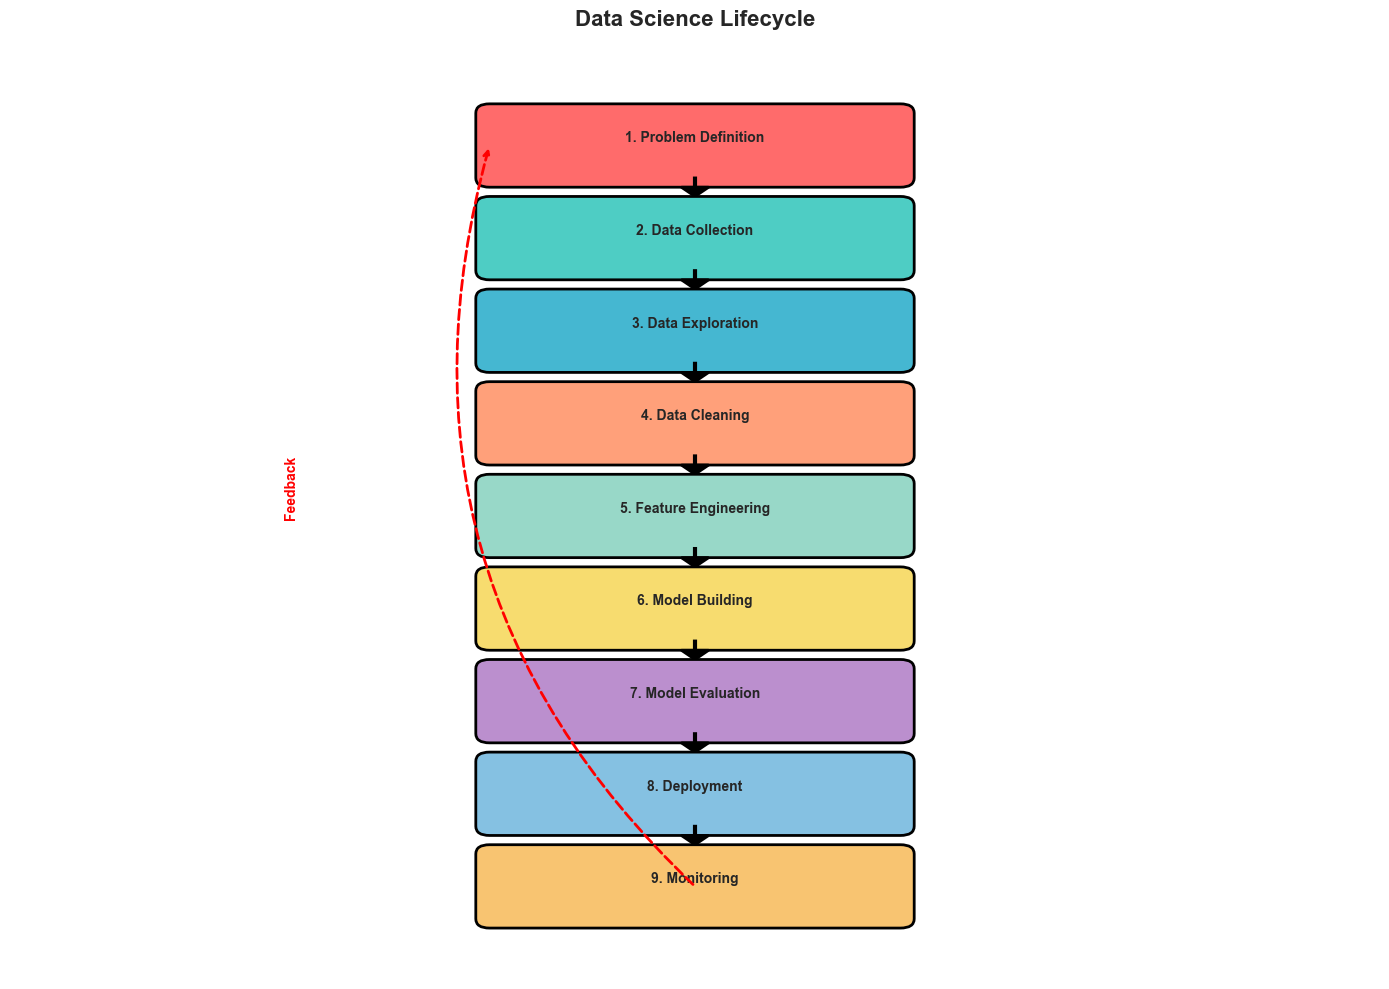

In [3]:
# PART 1: draw the 9-step data science lifecycle as a flow diagram - the roadmap this whole course follows
print("\n" + "=" * 70)
print("PART 1: Understanding the Data Science Lifecycle")
print("=" * 70)

print("\n📋 BEFORE: You know individual data science techniques but not how they connect")
print("📋 AFTER: You understand the complete lifecycle and where each step fits")
print("💡 WHY THIS MATTERS: The lifecycle shows you the big picture - where everything fits!\n")

print("\n1. Creating the Data Science Lifecycle Diagram")
print("-" * 70)

# Define the data science lifecycle steps
# Why these 9 steps? They represent the complete journey from problem to production
# Why in this order? Each step builds on the previous one - can't skip steps!
lifecycle_steps = [
"1. Problem Definition\n ", "2. Data Collection\n ",
"3. Data Exploration\n ",
"4. Data Cleaning\n ",
"5. Feature Engineering\n ",
"6. Model Building\n ",
"7. Model Evaluation\n ",
"8. Deployment\n",
"9. Monitoring\n"
]
# Create a flowchart-style visualization
fig, ax = plt.subplots(figsize=(14, 10))
# Colors for different phases
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
'#F7DC6F', '#BB8FCE', '#85C1E2', '#F8C471']
# Draw lifecycle steps as boxes
y_positions = np.linspace(0.9, 0.1, len(lifecycle_steps))
box_width = 0.3
box_height = 0.07
for i, (step, y_pos, color) in enumerate(zip(lifecycle_steps, y_positions, colors)):
    # Draw box
    box = FancyBboxPatch(
        (0.35, y_pos - box_height/2), box_width, box_height,
        boxstyle="round,pad=0.01",
        facecolor=color,
        edgecolor='black',
        linewidth=2,
        transform=ax.transAxes
    )
    ax.add_patch(box)
    # Add text
    ax.text(0.5, y_pos, step, ha='center', va='center',
            transform=ax.transAxes, fontsize=10, weight='bold')
    # Draw arrow to next step (except for last)
    if i < len(lifecycle_steps) - 1:
        ax.arrow(0.5, y_pos - box_height/2, 0, -0.01,
                transform=ax.transAxes, head_width=0.02, head_length=0.01,
                fc='black', ec='black', linewidth=2)
# Add feedback loop from Monitoring to Problem Definition
ax.annotate('', xy=(0.35, 0.9), xytext=(0.5, 0.1),
arrowprops=dict(arrowstyle='->', lw=2, color='red', linestyle='--',
connectionstyle="arc3,rad=-0.3"),
transform=ax.transAxes)
ax.text(0.2, 0.5, 'Feedback\n ', transform=ax.transAxes,
fontsize=10, color='red', weight='bold', rotation=90)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Data Science Lifecycle', fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('data_science_lifecycle.png', dpi=300, bbox_inches='tight')
print("✓ Lifecycle diagram saved as 'data_science_lifecycle.png'")

## Part 2: Working with Data Structures

**BEFORE**: You have raw data files that you can't use.

**AFTER**: You'll have a pandas DataFrame - structured data ready for analysis!

**Why this matters**: DataFrames are the foundation of all data science work!

## Step 2: Loading Real Data

**BEFORE**: We need to learn data structures, but we need data to practice on.

**AFTER**: We'll load a real 911 emergency-call log into a pandas DataFrame!

**Why real data?** Because real data is exactly what you will be paid to handle.
This file has missing values, free-text fields and uneven daily volume - the
messiness *is* the subject of this course, not a distraction from it.


In [4]:
# WHAT: Load the real Montgomery County 911 call log and take a first look (shape, head, dtypes, describe).
# WHY: Every later workflow step needs a table to work on - and a real one immediately shows what real data looks like.

print("\n" + "=" * 70)
print("PART 2: Working with Data Structures")
print("=" * 70)

print("\n📋 BEFORE: You have a raw data file that you can't use yet")
print("📋 AFTER: You have a pandas DataFrame - structured data ready for analysis")
print("💡 WHY THIS MATTERS: DataFrames are the foundation of all data science work!\n")

print("\n2. Loading the Real Dataset")
print("-" * 70)

# The dataset lives once in the repository and is shared by several courses.
# Why a relative path? It works on every machine without editing the notebook.
DATA_DIR = '../../../Course 04/datasets/raw/'

# Why usecols? The file has 9 columns and is ~123 MB. We read only the 6 we need,
# which keeps memory low and loading fast - a habit worth forming early.
df = pd.read_csv(
    DATA_DIR + 'montgomery_911_calls.csv',
    usecols=['lat', 'lng', 'title', 'timeStamp', 'twp', 'zip'],
)

# Why to_datetime? A timestamp read from CSV arrives as text. Converting it unlocks
# .dt accessors, resampling and time-based plotting.
df['timeStamp'] = pd.to_datetime(df['timeStamp'])

# The 'title' column looks like "EMS: BACK PAINS/INJURY" - the part before the colon
# is the emergency category. Splitting it gives us a clean categorical column.
df['category'] = df['title'].str.split(':').str[0]

print("\n✅ Real data loaded successfully!")
print(f"📊 Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"   - Each row is ONE 911 call placed in Montgomery County, PA")
print(f"   - Columns are the facts recorded about that call")
print(f"   - Time covered: {df['timeStamp'].min().date()} to {df['timeStamp'].max().date()}")

print("\n📋 First 5 rows (head of data):")
print(df[['timeStamp', 'category', 'twp', 'lat', 'lng']].head())  # 5 of the columns, so it fits the screen

print("\n📋 Data Types:")
print(df.dtypes)  # Why dtypes? Shows what type of data each column contains
print("   - Understanding types helps us know what operations are possible")

print("\n📋 Basic Statistics (numeric columns only):")
print(df[['lat', 'lng']].describe())  # Why describe()? Summary statistics (mean, std, min, max)
print("   - lat/lng are coordinates, so their 'mean' is roughly the centre of the county")
print("   - Look at the min/max: Montgomery County sits near 40.1 N, -75.3 W, yet the")
print("     table shows impossible values. Count how many rows are off the county:")
off_county = ((df['lat'] < 39.9) | (df['lat'] > 40.5) |
              (df['lng'] < -75.8) | (df['lng'] > -74.9)).sum()
print(f"     {off_county} of {len(df):,} rows have coordinates outside the county.")
print("   - Nobody planted those errors: this is what a real dispatch log contains.")
print("     Unit 2 (Outliers) shows how to find and handle them properly.")



PART 2: Working with Data Structures

📋 BEFORE: You have a raw data file that you can't use yet
📋 AFTER: You have a pandas DataFrame - structured data ready for analysis
💡 WHY THIS MATTERS: DataFrames are the foundation of all data science work!


2. Loading the Real Dataset
----------------------------------------------------------------------



✅ Real data loaded successfully!
📊 Dataset Shape: 663,522 rows, 7 columns
   - Each row is ONE 911 call placed in Montgomery County, PA
   - Columns are the facts recorded about that call
   - Time covered: 2015-12-10 to 2020-07-29

📋 First 5 rows (head of data):
            timeStamp category                twp        lat        lng
0 2015-12-10 17:10:52      EMS        NEW HANOVER  40.297876 -75.581294
1 2015-12-10 17:29:21      EMS  HATFIELD TOWNSHIP  40.258061 -75.264680
2 2015-12-10 14:39:21     Fire         NORRISTOWN  40.121182 -75.351975
3 2015-12-10 16:47:36      EMS         NORRISTOWN  40.116153 -75.343513
4 2015-12-10 16:56:52      EMS   LOWER POTTSGROVE  40.251492 -75.603350

📋 Data Types:
lat                 float64
lng                 float64
zip                 float64
title                object
timeStamp    datetime64[ns]
twp                  object
category             object
dtype: object
   - Understanding types helps us know what operations are possible

📋 Basic S

## Part 3: Following the Data Science Workflow

**BEFORE**: You have data but no clear direction.

**AFTER**: You'll have a clear workflow from problem to solution!

**Why this matters**: Following the workflow ensures you don't miss important steps!

## Step 3: Walking Through the Workflow

**BEFORE**: We have data but don't know how to use it systematically.

**AFTER**: We'll follow the data science workflow step by step!

**Why follow workflow?** It ensures we don't skip important steps and build things systematically!

In [5]:
# WHAT: Walk the first four lifecycle steps (define problem -> collect -> explore -> analyse) on the real 911 data.
# WHY: Acting out each abstract step on a concrete dataset makes the workflow memorable and repeatable.

print("\n" + "=" * 70)
print("PART 3: Following the Data Science Workflow")
print("=" * 70)

print("\n📋 BEFORE: You have data but no clear direction")
print("📋 AFTER: You have a clear workflow from problem to solution")
print("💡 WHY THIS MATTERS: Following the workflow ensures you don't miss important steps!\n")

print("\n3. Walking Through the Data Science Workflow")
print("-" * 70)

# Step 1: Problem Definition
# Why FIRST? Without a clear problem, you don't know what to solve!
print("\n📌 Step 1: Problem Definition")
print("   Problem: How many 911 calls should the county expect on a given day,")
print("            and which emergency categories drive that volume?")
print("   Why define problem first? It guides all subsequent steps!")
print("   Without a clear problem, you'll analyse data aimlessly")

# Step 2: Data Collection
# Here the collection step is already done for us - the county publishes the log.
print("\n📌 Step 2: Data Collection")
print(f"   ✓ Collected {len(df):,} data points (rows)")
print(f"   ✓ Each row represents one emergency call")
print(f"   Why collect data? Data is the raw material for all analysis!")

# Step 3: Data Exploration
# Why THIRD? You need to understand your data before cleaning or modelling.
print("\n📌 Step 3: Data Exploration")
missing_per_col = df.isnull().sum()
missing_count = missing_per_col.sum()
print(f"   ✓ Found {missing_count:,} missing values in total")
for col, n in missing_per_col[missing_per_col > 0].items():
    print(f"     - {col}: {n:,} missing ({n / len(df) * 100:.1f}% of rows)")
print(f"   ✓ Data ranges from {df['timeStamp'].min()} to {df['timeStamp'].max()}")
print("   Why explore first? Understanding data helps you make informed decisions!")
print("   Those gaps are REAL - dispatchers could not always record a ZIP code.")
print("   Missing values? We'll handle exactly these in Unit 2 (Data Cleaning)")

# Step 4: Basic Analysis
# Why do analysis? To find patterns and insights before building any model.
print("\n📌 Step 4: Initial Analysis")

# resample('D').size() counts the rows falling in each calendar day - a daily time series.
daily_calls = df.set_index('timeStamp').resample('D').size()
avg_daily = daily_calls.mean()
print(f"   ✓ Average calls per day: {avg_daily:.1f}")
print(f"   ✓ Quietest day: {daily_calls.min():,} calls | Busiest day: {daily_calls.max():,} calls")
print(f"   Why calculate averages? They give us a baseline to compare against!")
print(f"   Any staffing forecast has to beat 'just predict {avg_daily:.0f} calls every day'")

print("\n   Calls by emergency category:")
category_counts = df['category'].value_counts()
for cat, n in category_counts.items():
    print(f"     - {cat}: {n:,} calls ({n / len(df) * 100:.1f}%)")



PART 3: Following the Data Science Workflow

📋 BEFORE: You have data but no clear direction
📋 AFTER: You have a clear workflow from problem to solution
💡 WHY THIS MATTERS: Following the workflow ensures you don't miss important steps!


3. Walking Through the Data Science Workflow
----------------------------------------------------------------------

📌 Step 1: Problem Definition
   Problem: How many 911 calls should the county expect on a given day,
            and which emergency categories drive that volume?
   Why define problem first? It guides all subsequent steps!
   Without a clear problem, you'll analyse data aimlessly

📌 Step 2: Data Collection
   ✓ Collected 663,522 data points (rows)
   ✓ Each row represents one emergency call
   Why collect data? Data is the raw material for all analysis!

📌 Step 3: Data Exploration
   ✓ Found 80,492 missing values in total
     - zip: 80,199 missing (12.1% of rows)
     - twp: 293 missing (0.0% of rows)
   ✓ Data ranges from 2015-12-10 1

## Part 4: Visualizing the Data

**BEFORE**: You have numbers in tables (hard to understand).

**AFTER**: You'll have visual plots (easy to understand patterns)!

**Why this matters**: A picture is worth a thousand numbers - visualizations reveal patterns!

## Step 4: Creating Data Visualizations

**BEFORE**: We have numbers in tables - hard to see patterns.

**AFTER**: We'll create visual plots that make patterns obvious!

**Why visualize?** Humans understand pictures better than numbers! Visualizations help us see trends, patterns, and relationships.


PART 4: Visualizing the Data

📋 BEFORE: You have numbers in tables (hard to understand)
📋 AFTER: You have visual plots (easy to understand patterns)
💡 WHY THIS MATTERS: A picture is worth a thousand numbers - visualizations reveal patterns!


4. Creating Data Visualizations
----------------------------------------------------------------------
   Why visualize? Humans understand pictures better than numbers!
   Visualizations help us see trends, patterns, and relationships



✓ Data overview plots saved as 'data_overview.png'
✓ Fire and Traffic call counts move together: correlation r = 0.66
  A plausible reason: storms and bad road conditions generate both at once.


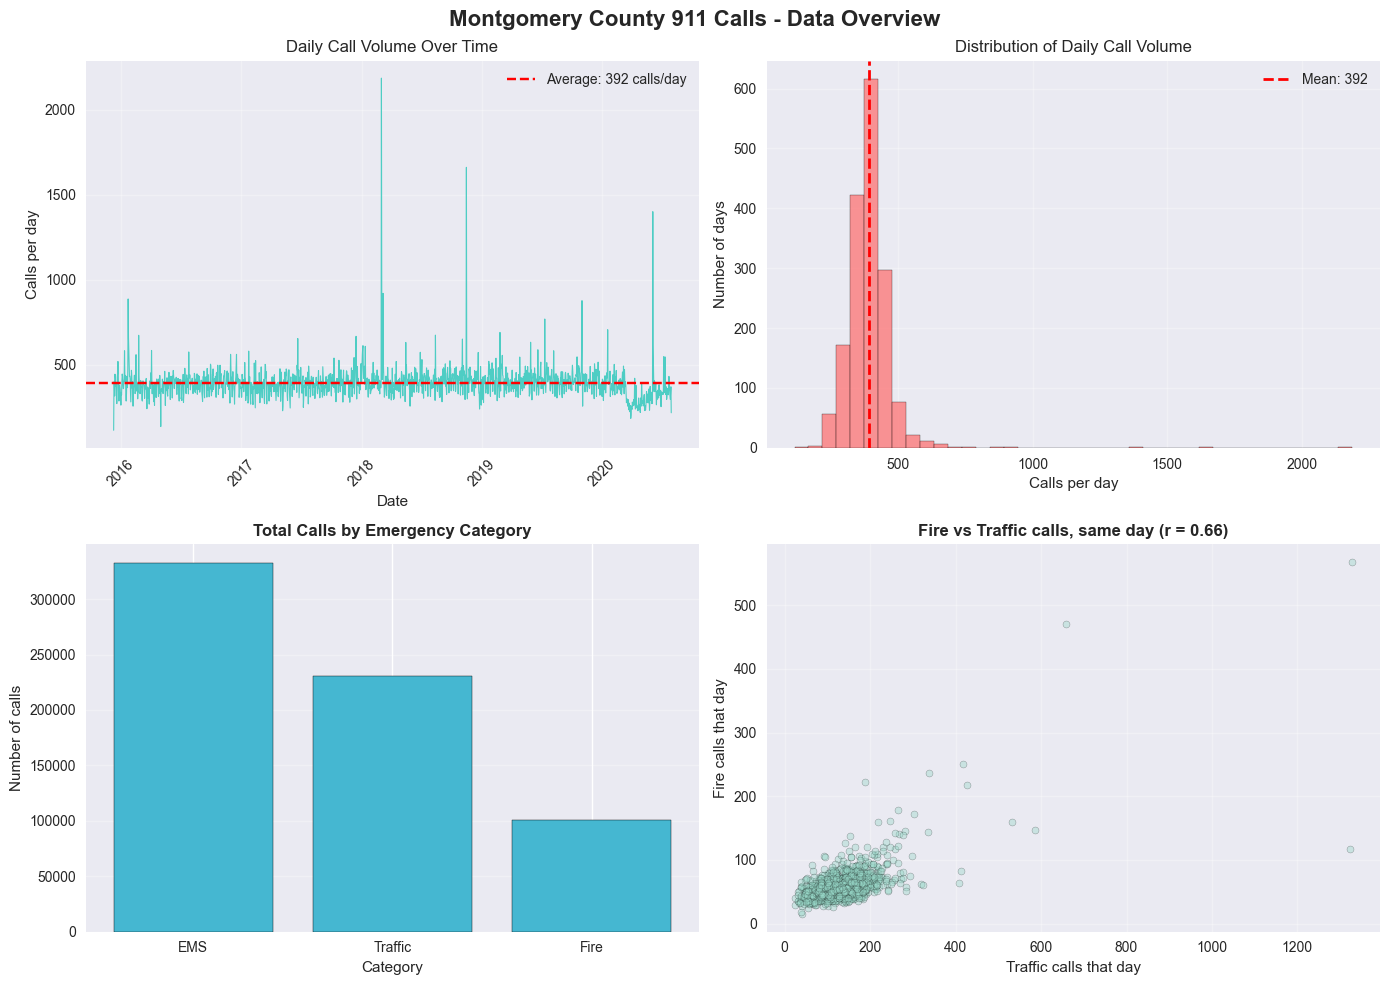

In [6]:
# PART 4: plot the real call log four ways (line, histogram, bar, scatter) - pictures reveal patterns tables hide
print("\n" + "=" * 70)
print("PART 4: Visualizing the Data")
print("=" * 70)

print("\n📋 BEFORE: You have numbers in tables (hard to understand)")
print("📋 AFTER: You have visual plots (easy to understand patterns)")
print("💡 WHY THIS MATTERS: A picture is worth a thousand numbers - visualizations reveal patterns!\n")

print("\n4. Creating Data Visualizations")
print("-" * 70)
print("   Why visualize? Humans understand pictures better than numbers!")
print("   Visualizations help us see trends, patterns, and relationships\n")

# A daily count PER CATEGORY - one column per category, one row per day.
# unstack() turns the category level of the index into columns.
daily_by_cat = (df.set_index('timeStamp')
                  .groupby('category')['title']
                  .resample('D')
                  .size()
                  .unstack(0)
                  .fillna(0))

# Create subplots - 4 plots in one figure
# Why subplots(2, 2)? Shows multiple views of data side-by-side for comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Montgomery County 911 Calls - Data Overview', fontsize=16, weight='bold')

# Plot 1: Calls over time
# Why line plot? Shows trends and patterns over time
axes[0, 0].plot(daily_calls.index, daily_calls.values, color='#4ECDC4', linewidth=0.8)
axes[0, 0].axhline(y=avg_daily, color='r', linestyle='--',
                   label=f'Average: {avg_daily:.0f} calls/day')
axes[0, 0].set_title('Daily Call Volume Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Calls per day')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Distribution of daily volume (histogram)
# Why histogram? Shows how often each level of daily demand actually occurs
axes[0, 1].hist(daily_calls.values, bins=40, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=avg_daily, color='r', linestyle='--', linewidth=2,
                   label=f'Mean: {avg_daily:.0f}')
axes[0, 1].set_title('Distribution of Daily Call Volume')
axes[0, 1].set_xlabel('Calls per day')
axes[0, 1].set_ylabel('Number of days')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Calls by category (bar chart)
# Why bar chart? Easy to compare values across categories
axes[1, 0].bar(category_counts.index, category_counts.values,
               color='#45B7D1', edgecolor='black')
axes[1, 0].set_title('Total Calls by Emergency Category', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Number of calls')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Do busy Fire days coincide with busy Traffic days? (scatter plot)
# Why scatter plot? Shows the relationship between two variables measured on the same days
corr_ft = daily_by_cat['Fire'].corr(daily_by_cat['Traffic'])
axes[1, 1].scatter(daily_by_cat['Traffic'], daily_by_cat['Fire'],
                   alpha=0.4, color='#98D8C8', s=25, edgecolors='black', linewidth=0.3)
axes[1, 1].set_title(f'Fire vs Traffic calls, same day (r = {corr_ft:.2f})',
                     fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Traffic calls that day')
axes[1, 1].set_ylabel('Fire calls that day')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data_overview.png', dpi=300, bbox_inches='tight')
print("✓ Data overview plots saved as 'data_overview.png'")
print(f"✓ Fire and Traffic call counts move together: correlation r = {corr_ft:.2f}")
print("  A plausible reason: storms and bad road conditions generate both at once.")


## 💬 Discuss

The plots above report a measured **r = 0.66** between monthly Fire calls and monthly
Traffic calls, and the notebook offers one plausible reason: storms produce both at once.
Argue about it before you move on.

1. Give a *second* explanation for that 0.66 that has nothing to do with weather. (Hint:
   what else makes two different call counts rise in the same month?) What single extra
   column would let you tell your explanation apart from the notebook's — and is that
   column in this file?
2. Wal-Mart moved trucks on a pattern found in past sales. Suppose the 0.66 holds up.
   Would you pre-position a fire crew on the strength of it? Say what evidence you would
   demand first, and name the cost of being wrong in each direction — crew idle in the
   wrong township, versus crew missing from the right one.
3. Step 1 of the lifecycle is Problem Definition. This one table supports "how many calls
   will we get tomorrow?" and "which calls are life-threatening?" — same rows, different
   problems. Pick one, then argue why the *other* is the harder one to sell to a county
   official who controls the budget.


## 🎯 Summary: What We Learned

In [7]:
# WHAT: Print a recap of the concepts this notebook covered and what comes next.
# WHY: Restating the lifecycle in one place helps you check your understanding before moving on.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this example:")
print("   - You knew Python but not the data science workflow")
print("   - You had heard of pandas but didn't understand DataFrames")
print("   - You didn't know how all data science steps connect")

print("\n✅ AFTER this example:")
print("   - You understand the complete data science lifecycle (9 steps)")
print("   - You can load a real CSV into a DataFrame and inspect it")
print("   - You can create basic visualizations")
print("   - You see how the workflow guides all data science work")

print("\n📚 Key Concepts Covered:")
print("   1. Data Science Lifecycle (9 steps: Problem → Monitoring)")
print("   2. Pandas DataFrames (structured data tables) loaded from a real CSV")
print("   3. Data Exploration (shape, dtypes, missing values, date range)")
print("   4. Basic Visualizations (line plots, histograms, bar charts, scatter plots)")

print("\n🔗 Where Each Step Fits in the Lifecycle:")
print("   - This example covered: Problem Definition, Data Collection,")
print("     Data Exploration, and Initial Analysis")
print("   - Next: Example 2 will dive deeper into data manipulation (pandas/NumPy)")
print("   - Then: Example 3 will show GPU acceleration (cuDF)")

print("\n➡️  Next Steps:")
print("   - Continue to Example 2: Pandas & NumPy Basics")
print("   - You'll learn more about manipulating DataFrames and arrays")
print("   - This builds on what you learned about data structures here!")

print("\n" + "=" * 70)
# Render any figures still pending so they appear below this cell
plt.show()



🎯 SUMMARY: What We Learned

📋 BEFORE this example:
   - You knew Python but not the data science workflow
   - You had heard of pandas but didn't understand DataFrames
   - You didn't know how all data science steps connect

✅ AFTER this example:
   - You understand the complete data science lifecycle (9 steps)
   - You can load a real CSV into a DataFrame and inspect it
   - You can create basic visualizations
   - You see how the workflow guides all data science work

📚 Key Concepts Covered:
   1. Data Science Lifecycle (9 steps: Problem → Monitoring)
   2. Pandas DataFrames (structured data tables) loaded from a real CSV
   3. Data Exploration (shape, dtypes, missing values, date range)
   4. Basic Visualizations (line plots, histograms, bar charts, scatter plots)

🔗 Where Each Step Fits in the Lifecycle:
   - This example covered: Problem Definition, Data Collection,
     Data Exploration, and Initial Analysis
   - Next: Example 2 will dive deeper into data manipulation (pandas/Nu

## 🚫 When Data Science Lifecycle Hits a Dead End

**BEFORE**: We understand the lifecycle and workflow conceptually.

**AFTER**: We realize we need actual tools to manipulate data in Python!

**Why this matters**: Understanding the lifecycle is great, but we need practical skills to actually work with data!

---

### The Problem We've Discovered

We've learned:
- ✅ The complete data science lifecycle (9 steps)
- ✅ What DataFrames are conceptually
- ✅ How to create basic visualizations

**But we have a problem:**
- ❓ **How do we actually manipulate data in Python?**
- ❓ **What are the specific tools and techniques?**
- ❓ **How do we filter, transform, and analyze data programmatically?**

**The Dead End:**
- We understand **what** to do (the lifecycle)
- But we don't know **how** to do it (the tools and techniques)
- We need to learn pandas and NumPy to actually work with data!

---

### What We Need Next

**The Solution**: We need to learn the actual tools:
- **pandas**: For working with DataFrames (tables of data)
- **NumPy**: For numerical operations and arrays
- **Data manipulation techniques**: Filtering, grouping, transforming

**This dead end leads us to Example 2: Pandas & NumPy Basics**
- Example 2 will teach us the practical skills to actually manipulate data
- We'll learn how to use pandas and NumPy to do real data science work
- This bridges the gap between understanding the lifecycle and actually implementing it!

## ⚠️ Where this breaks

The nine-step lifecycle is a map, not a law. Three honest caveats:

- **The diagram is a loop; real projects run backwards.** In this very notebook, step 3
  (exploration) found 80,199 rows with no ZIP code. That discovery sends you back to step 1
  to redefine the problem — you cannot answer "which ZIP codes call most?" on this file.
  Anyone who presents the lifecycle as a one-way conveyor belt has not shipped a project.
- **The assumption that must hold is that tomorrow resembles yesterday.** Every step from
  4 onwards silently assumes the data-generating process is stable. This log contains the
  March–April 2020 COVID lockdown, when it stopped being stable. A lifecycle followed
  perfectly through step 8 still produces a broken system if step 9 is skipped — that is
  precisely what happened to Google Flu Trends.
- **Steps 1 and 9 are the ones teams skip, and they are the expensive ones.** Steps 3–6
  are the fun part and get all the tutorial attention. The failures that make the news
  live at the two ends.
- **When it is overkill:** for a one-off question with a known answer shape — "how many
  calls came from Norristown last March?" — a single `groupby` is the whole project. Do
  not run a nine-step process to answer a question a filter answers. Reach for the full
  lifecycle when a decision will be repeated, automated, or defended.

**The same reasoning turns up elsewhere:** an epidemiologist re-checking a surveillance
dashboard each season; a bank re-validating a credit scorecard after a rate shock; a
retailer re-fitting demand forecasts after a supply-chain break. In all three, the
technique was never the problem — the missing re-measurement was.


## 📚 References

1. Tukey, J. W. (1962). *The Future of Data Analysis*. The Annals of Mathematical Statistics, 33(1), 1-67.
2. Donoho, D. (2017). *50 Years of Data Science*. Journal of Computational and Graphical Statistics, 26(4), 745-766. <https://doi.org/10.1080/10618600.2017.1384734>
3. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-92bf1922-00a>